## Apartado 3. Búsqueda de hilos similares.

In [5]:
import zstandard as zstd
import json
import argparse
import io
import sys
from pathlib import Path
from datetime import datetime, UTC
import random
import os
import pandas as pd

Vamos a cargar el mismo modelo de fasttext que usamos en el apartado 2.

In [6]:
# !pip install fasttext
import fasttext
ft_model = fasttext.load_model('crawl-300d-2M-subword.bin')

In [11]:
subreddits = ["onepiece", "soccer", "gaming", "movies", "leagueoflegends", "drawing"]

rows = []
for subreddit in subreddits:
    filename = subreddit + '_final.json'

    if not os.path.exists(filename):
        print(f"No existe {filename}, se salta.")
        continue

    print(f"\nProcesando {filename}...")

    # Abrir JSON
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Aquí guardaremos los textos de un subreddit en concreto
    

    # Recorrer submissions
    for submission in data["submissions"]:

        # TEXTO DEL POST: juntamos título con texto del post
        texto_hilo = (submission.get("title", "") + " " + submission.get("selftext", "")).strip()

        # Añadimos ahora el texto de los comentarios del hilo
        for comment in submission.get("comments", []):
            body = comment.get("body", "").strip()

            # Guardamos el comentario si no está vacío
            if body:
                texto_hilo += body
                
        rows.append({
                    "subreddit": subreddit,
                    "texto": texto_hilo
                })
                

# Crear DataFrame
df = pd.DataFrame(rows)
df["texto"] = df["texto"].apply(lambda x: x.replace("\n", " "))


Procesando onepiece_final.json...

Procesando soccer_final.json...

Procesando gaming_final.json...

Procesando movies_final.json...

Procesando leagueoflegends_final.json...

Procesando drawing_final.json...


In [12]:
df["sentence_embeddings"] = df["texto"].apply(lambda x: ft_model.get_sentence_vector(x))
df.head()

,subreddit,texto,sentence_embeddings
0,onepiece,Official 🚨🚨🚨🚨🚨 Ace will be played by XOLODead ...,"[-0.0016739905, -0.012620177, 0.07350646, 0.00..."
1,onepiece,What is the symbol on dragon's face ? Is it a ...,"[-0.0012561227, -0.0059917225, 0.082547955, 0...."
2,onepiece,"What are exambles of ""bad devilfruits"" with go...","[-0.004081797, -0.017054116, 0.096680604, 0.01..."
3,onepiece,My Luffy live action cosplay Original sewed ve...,"[-0.0021282518, -0.025299337, 0.068572216, 0.0..."
4,onepiece,He's blonde??? Never expected for St Garling t...,"[-0.0048311288, -0.011010855, 0.086308576, 0.0..."


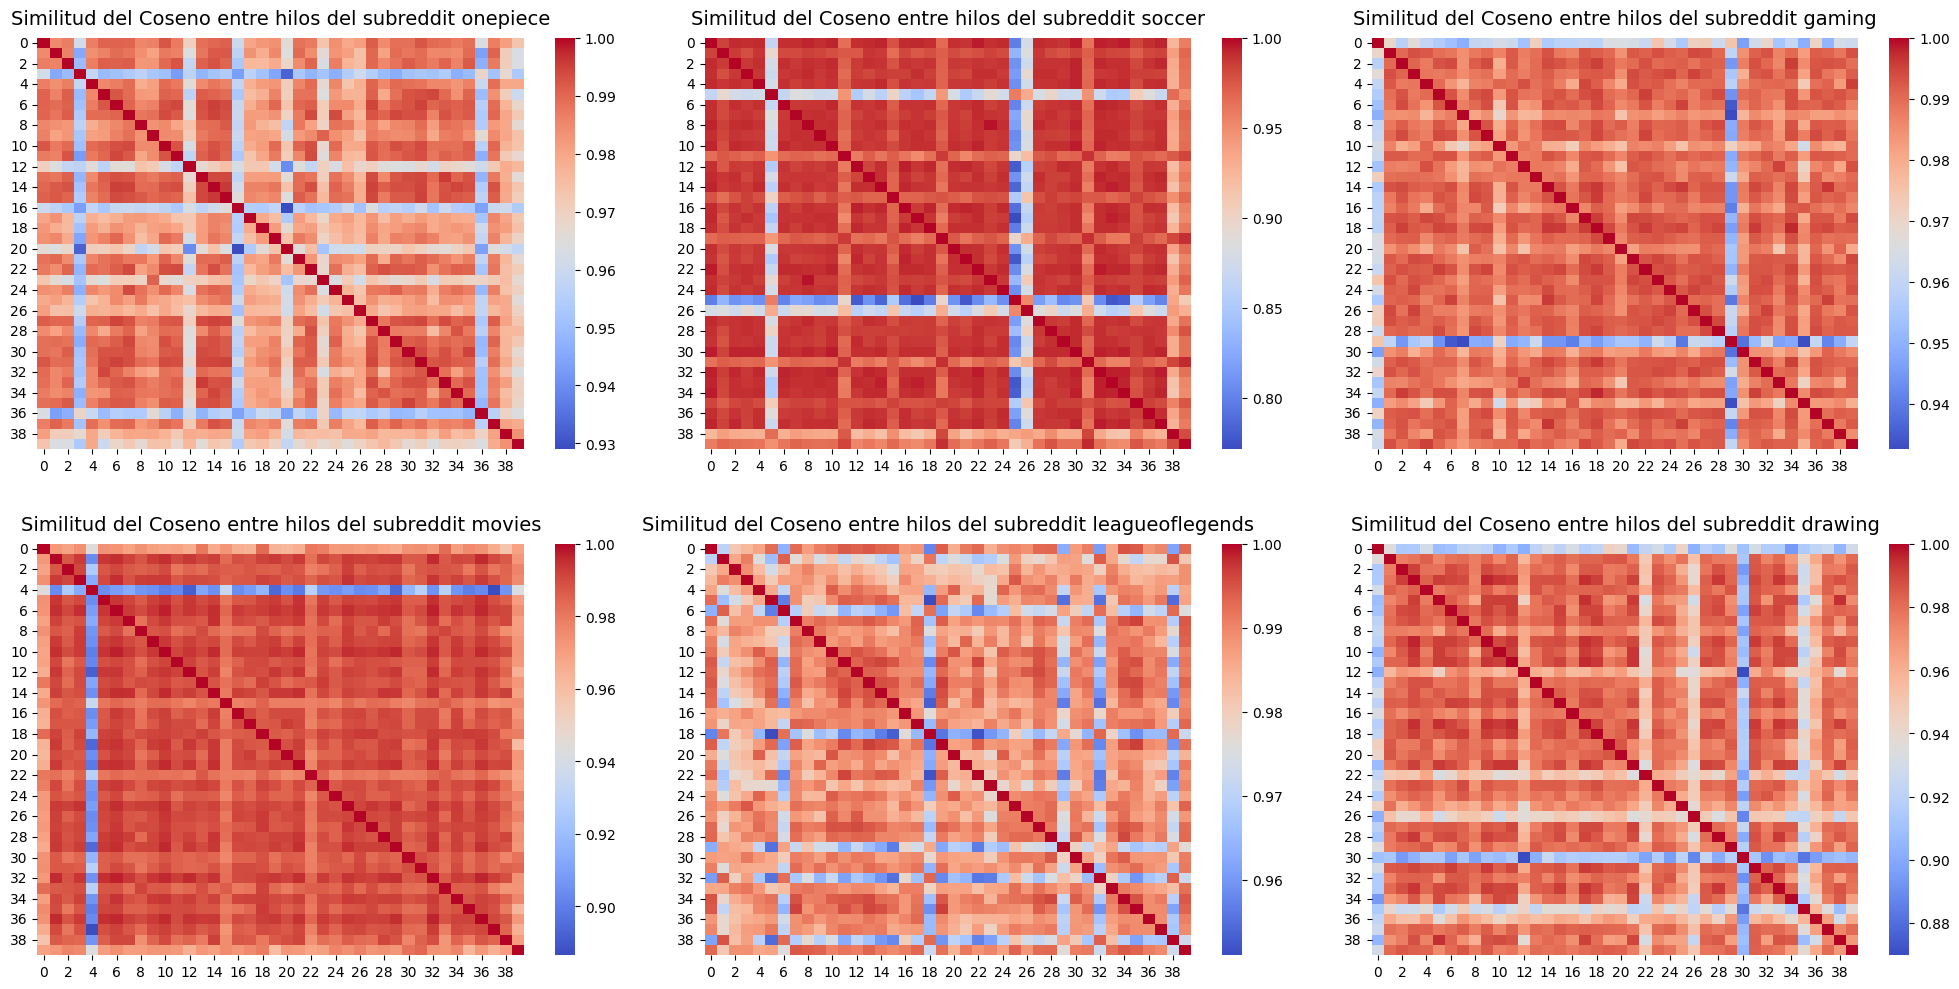

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df[df["subreddit"] == subreddit]
    # Para calcular la similaridad de los hilos, primero vamos a agrupar en una matriz de numpy todos los embeddings
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings'].values)
    # Con esta matriz, calculamos la similaridad entre los hilos
    matriz_similitud = cosine_similarity(matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True      
    )
    axes[i].set_title(f'Similitud del Coseno entre hilos del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

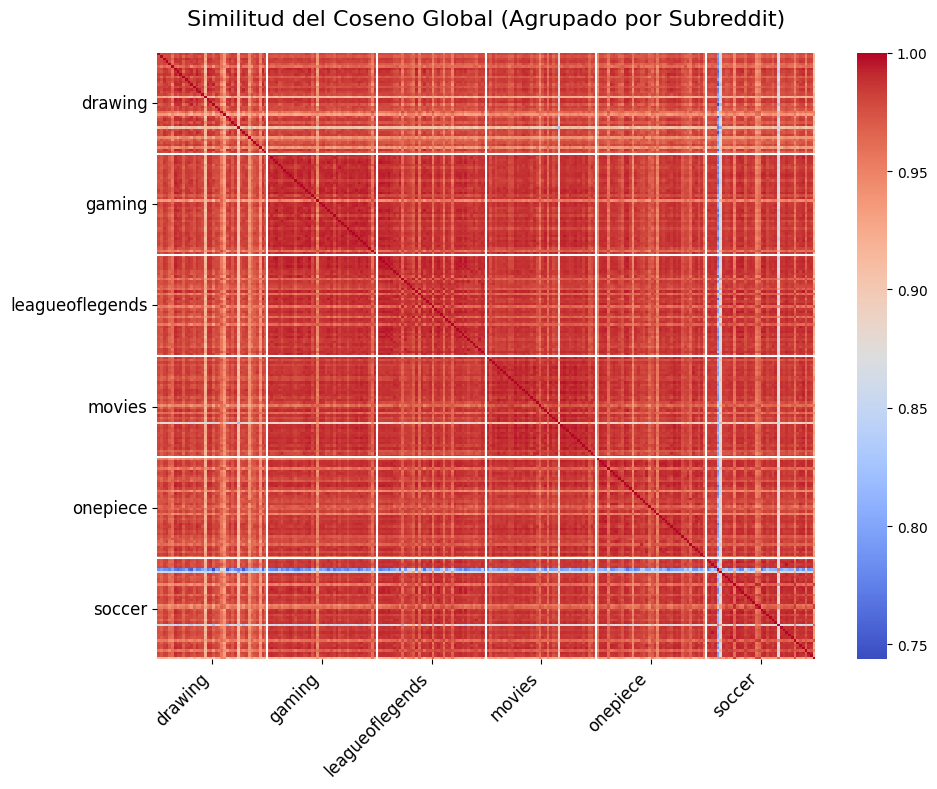

In [24]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = cosine_similarity(matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm'
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Observando el mapa de calor, vemos que praácticamente todos los hilos son muy similares entre sí, esto es lo esperado, ya que los textos no se han normalizado (eliminado las stop words, etc.). Además, cuando los hilos son muy largos, los vectores de tantas palabras tienden a mezclarse en distintas direcciones, y al promediarlos, el vector final tiende a apuntar al "centro" del idioma.

### Ahora vamos a realizar un pca para poder representar los sentence embeddings en un gráfico.

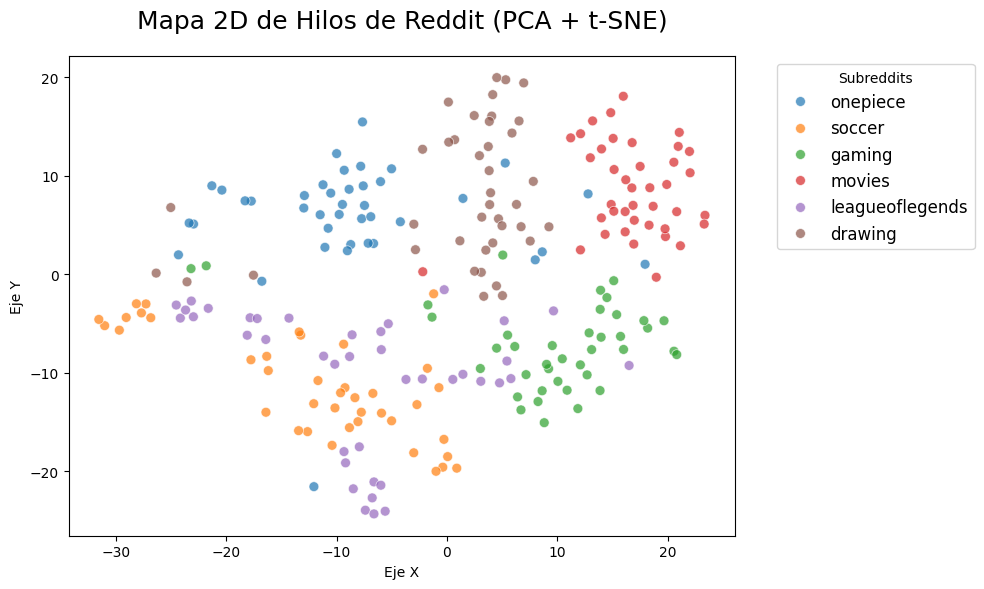

In [19]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

matriz_embeddings = np.vstack(df['sentence_embeddings'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

Viendo el gráfico resultante, los hilos de un mismo subreddit tienden a agruparse en la misma zona, sin embargo, se siguen mezclando hilos de distintos subreddits, y en algunos casos parece muy complicado de diferenciar a que subreddit pertenecen, en el centro de la gráfica hay al menos un hilo de todos los subreddits.

### Ahora vamos a normalizar el texto de los hilos y ver si con esto mejora la distintividad de los hilos.

Para esto, vamos a hacer uso de la misma función de limpieza que en el apartado 2.

In [3]:
import nltk
!pip install demoji
import demoji
import re
from nltk.corpus import stopwords

# Descargar recursos necesarios
nltk.download('stopwords')

# Stopwords en inglés
stop_words = set(stopwords.words('english'))

# Añadimos algunas palabras que son muy comunes en Reddit y no aportan mucho
stop_words.update(['edit', 'thanks', 'post', 'reddit'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\30mmn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
# Función de limpieza

def limpiar_texto(texto):

    # Eliminamos URLs
    texto = re.sub(r'http\S+|www\S+', ' ', texto)

    # Elimiamos emojis
    texto = demoji.replace(texto, "")
    
    # Eliminar menciones de Reddit tipo u/usuario o /u/usuario
    texto = re.sub(r'/?u\/\w+', ' ', texto)

    # Eliminar menciones tipo @usuario
    texto = re.sub(r'@\w+', ' ', texto)
    
    # Quitamos saltos de línea
    texto = texto.replace("\n", " ")

    # Separamos por espacios
    palabras = texto.split()

    # Quitamos las stopwords
    palabras_limpias = [p for p in palabras if p.lower() not in stop_words]

    # Volvemos a unir las palabras del texto en un string
    texto = " ".join(palabras_limpias)

    return texto

In [14]:
df["texto_clean"] = df["texto"].apply(lambda x: limpiar_texto(x))
df["sentence_embeddings_norm"] = df["texto_clean"].apply(lambda x: ft_model.get_sentence_vector(x))
df.head()

,subreddit,texto,sentence_embeddings,texto_clean,sentence_embeddings_norm
0,onepiece,Official 🚨🚨🚨🚨🚨 Ace will be played by XOLODead ...,"[-0.0016739905, -0.012620177, 0.07350646, 0.00...",Official Ace played XOLODead man walking.He be...,"[-0.00730918, -0.014850558, 0.06812135, 0.0021..."
1,onepiece,What is the symbol on dragon's face ? Is it a ...,"[-0.0012561227, -0.0059917225, 0.082547955, 0....",symbol dragon's face ? scar ? tattoo ? birthma...,"[-0.0075778267, -0.0059806216, 0.07478378, 0.0..."
2,onepiece,"What are exambles of ""bad devilfruits"" with go...","[-0.004081797, -0.017054116, 0.096680604, 0.01...","exambles ""bad devilfruits"" good users? Doflami...","[-0.010772706, -0.025095213, 0.08495754, 0.010..."
3,onepiece,My Luffy live action cosplay Original sewed ve...,"[-0.0021282518, -0.025299337, 0.068572216, 0.0...",Luffy live action cosplay Original sewed vest ...,"[-0.00669126, -0.030482812, 0.061244432, 0.011..."
4,onepiece,He's blonde??? Never expected for St Garling t...,"[-0.0048311288, -0.011010855, 0.086308576, 0.0...",blonde??? Never expected St Garling blonde. ac...,"[-0.012190034, -0.014664516, 0.07330867, 0.012..."


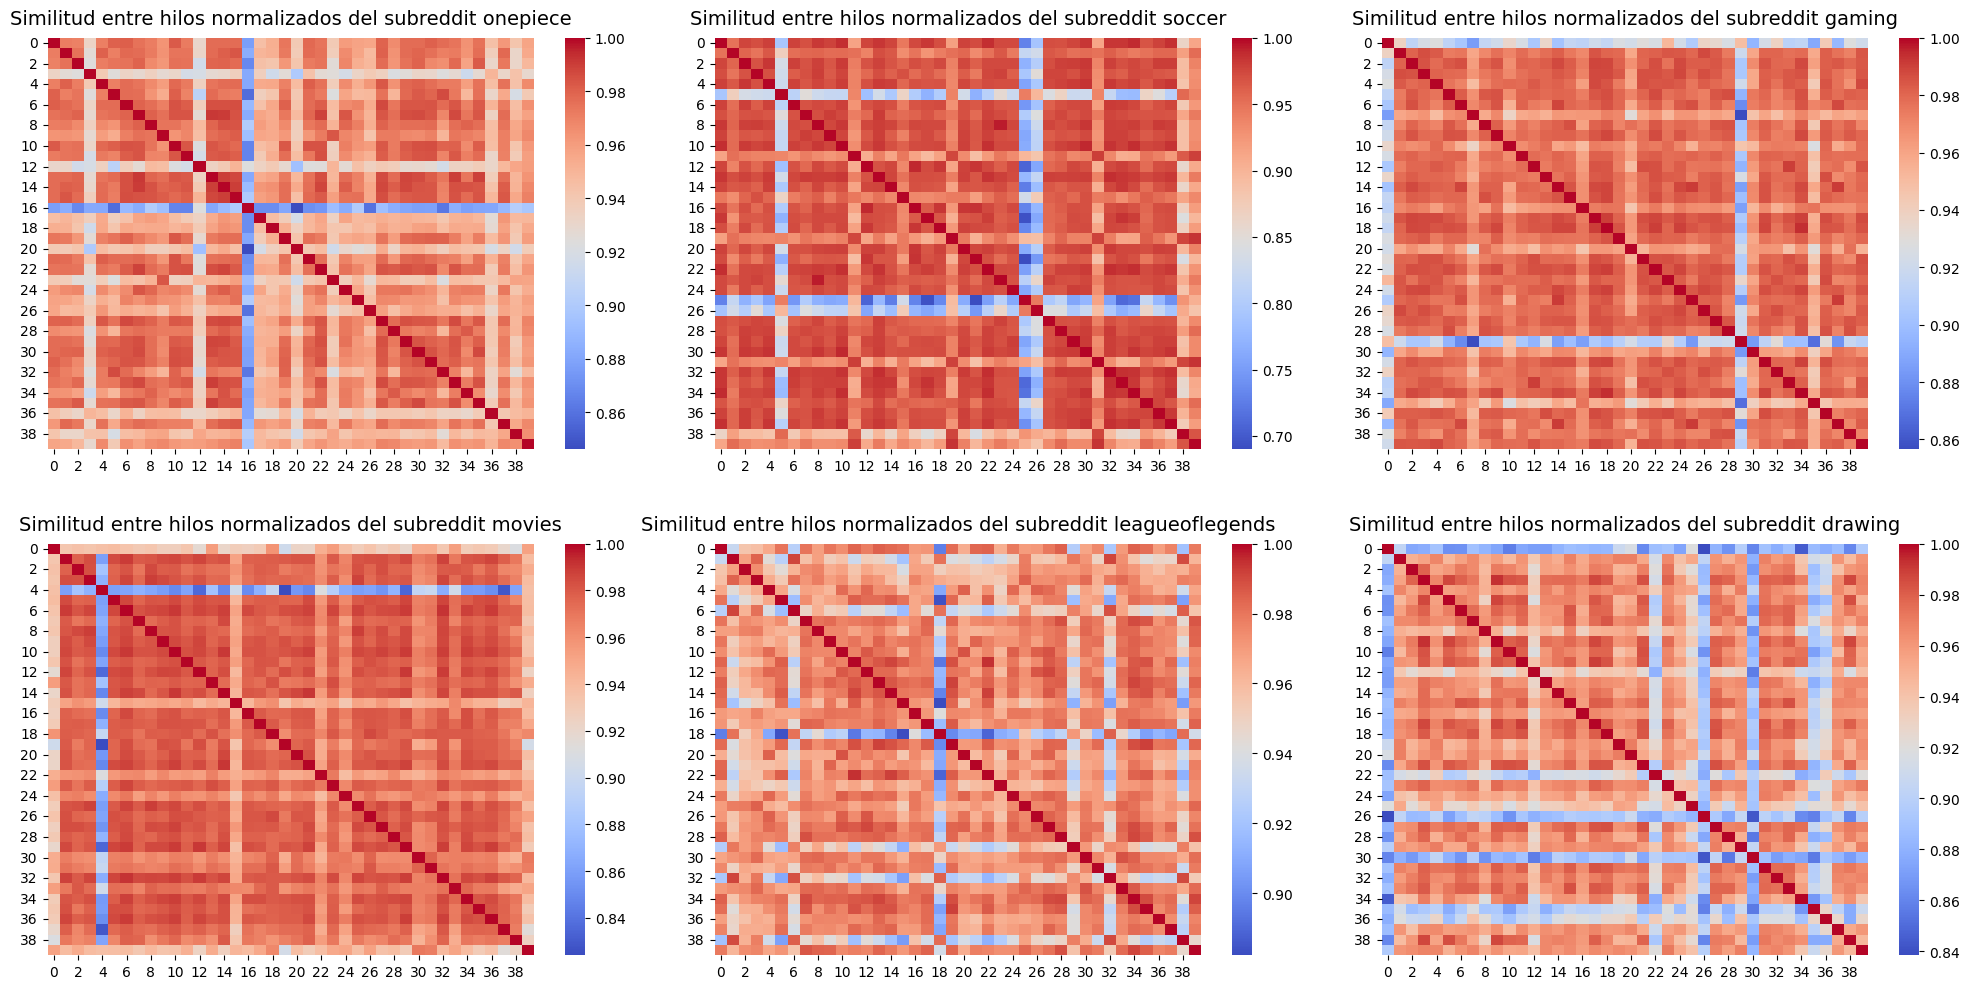

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axes = axes.flatten()

for i, subreddit in enumerate(subreddits):
    df_filtrado = df[df["subreddit"] == subreddit]
    # Para calcular la similaridad de los hilos, primero vamos a agrupar en una matriz de numpy todos los embeddings
    matriz_embeddings = np.vstack(df_filtrado['sentence_embeddings_norm'].values)
    # Con esta matriz, calculamos la similaridad entre los hilos
    matriz_similitud = cosine_similarity(matriz_embeddings)
    sns.heatmap(
        matriz_similitud, 
        cmap='coolwarm',         
        annot=False,
        ax= axes[i],
        cbar=True      
    )
    axes[i].set_title(f'Similitud entre hilos normalizados del subreddit {subreddit}', fontsize=14, pad=10)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()
    

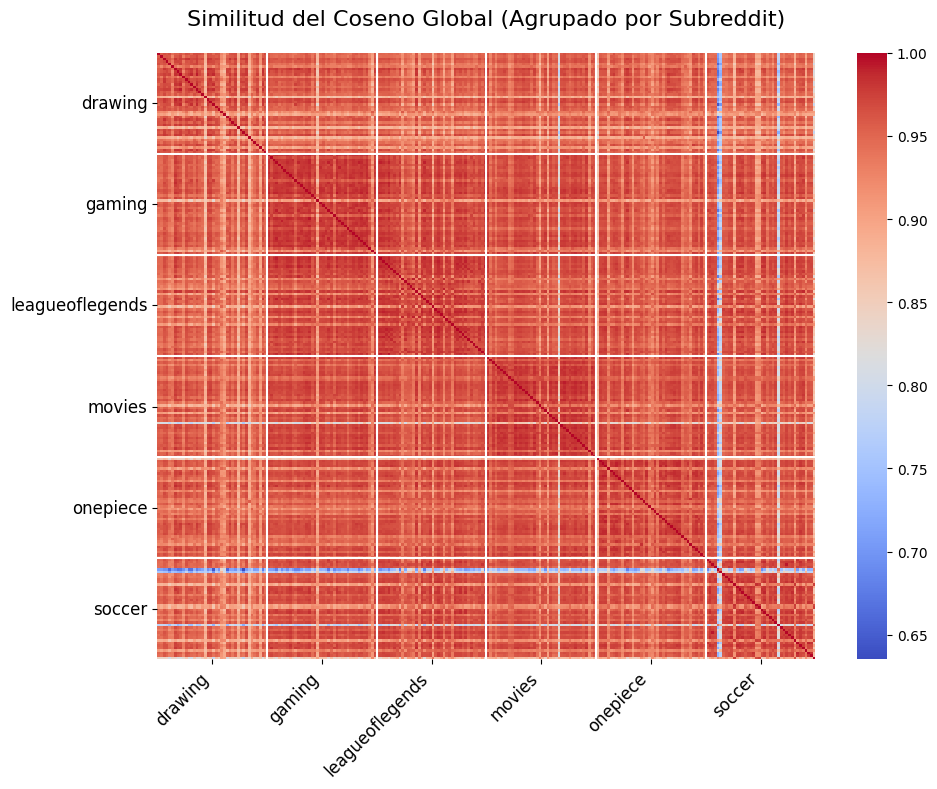

In [28]:
# Ahora generamos la matriz con todos los hilos de todos los subreddits
df_ordenado = df.sort_values(by='subreddit').reset_index(drop=True)
matriz_embeddings = np.vstack(df_ordenado['sentence_embeddings_norm'].values)
# Con esta matriz, calculamos la similaridad entre los hilos
matriz_similitud = cosine_similarity(matriz_embeddings)
conteos = df_ordenado['subreddit'].value_counts(sort=False)
subreddits_labels = conteos.index.tolist()

# Calculamos dónde termina un subreddit y empieza otro (suma acumulada)
bordes = conteos.cumsum().values
bordes_internos = bordes[:-1] # Quitamos el último porque es el borde final del dibujo

# Calculamos el centro de cada bloque para poner la etiqueta de texto exactamente en medio
centros = bordes - (conteos.values / 2)


plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_similitud, 
    cmap='coolwarm'
)

# Añadimos las líneas blancas separadoras
for borde in bordes_internos:
    ax.axhline(borde, color='white', lw=1.5) # Línea horizontal
    ax.axvline(borde, color='white', lw=1.5) # Línea vertical

# Ponemos los nombres de los subreddits en los centros calculados
ax.set_xticks(centros)
ax.set_xticklabels(subreddits_labels, rotation=45, ha='right', fontsize=12)

ax.set_yticks(centros)
ax.set_yticklabels(subreddits_labels, rotation=0, fontsize=12)

plt.title('Similitud del Coseno Global (Agrupado por Subreddit)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
    

Como vemos, aunque la similaridad general se ha reducido un porco (son rojos más claritos), todavía siguen siendo muy similares todos los hilos entre sí, por lo que con la normalización del texto no se aprecia mucha mejora, por lo menos en el mapa de calor. Aunque se hayan eliminado las stop words, sigue habiendo el mismo problema de que se produce un efecto "sopa".

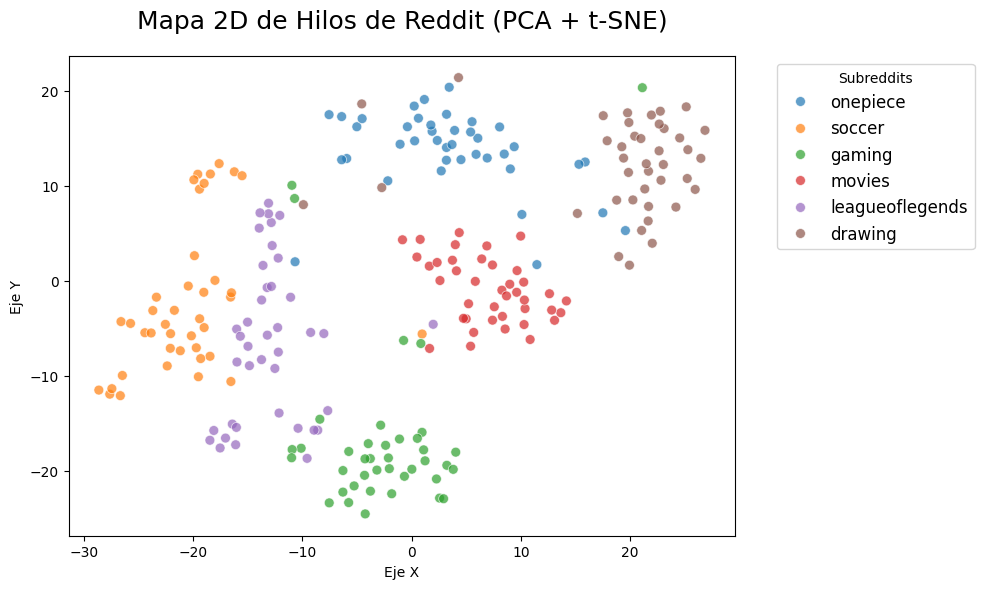

In [29]:
matriz_embeddings = np.vstack(df['sentence_embeddings_norm'].values)

# Guardamos la lista de a qué subreddit pertenece cada fila
etiquetas = df['subreddit'].values

# Primero reducimos la dimensionalidad a 50 con PCA
pca = PCA(n_components=50, random_state=42)
reduc = pca.fit_transform(matriz_embeddings)

# Ahora usamos otra técnica llamada TSNE para reducir la dimensionalidad a
# 2 dimensiones, y poder mostrarlo en una gráfica.
tsne = TSNE(perplexity=15, n_components=2, random_state=42)
coords = tsne.fit_transform(reduc)

# Juntamos las coordenadas y las etiquetas en un nuevo DataFrame
df_plot = pd.DataFrame({
    'Eje X': coords[:, 0],
    'Eje Y': coords[:, 1],
    'Subreddit': etiquetas
})

plt.figure(figsize=(10, 6))

# Dibujamos la gráfica en la que los puntos de los distintos subreddits tienen colores diferentes para diferenciarlos
sns.scatterplot(
    data=df_plot, 
    x='Eje X', 
    y='Eje Y', 
    hue='Subreddit', 
    palette='tab10',  
    s=50,             
    alpha=0.7         
)


plt.title('Mapa 2D de Hilos de Reddit (PCA + t-SNE)', fontsize=18, pad=20)
# Movemos la leyenda fuera del gráfico para que no tape los puntos
plt.legend(title='Subreddits', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

Viendo la gráfica con el texto de los hilos normalizado, ahora si que se aprecia claramente como los hilos de cada subreddit se agrupan en zonas distintas y hay poca mezcla de hilos de varios subreddits. Por lo que la normalización en este caso, si ha supuesto una mejora importante a la hora de discernir los distintos subreddits.

## Tarea adicional. Usar modelos sentence-transformers.

In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")